# Depression Risk Prediction Using Supervised Machine Learning
## M7015 AI Futures | Assessment 1 — Modelling Notebook

---

Depression is one of the leading causes of disability worldwide and a growing public health priority in the United Kingdom. 
According to NHS data, approximately one in six adults in England report experiencing a common mental health problem such as depression in any given week. 
Early identification of individuals at risk is therefore clinically valuable: it can support targeted screening, enable earlier intervention, and reduce the long-term burden on health services.

This notebook builds and rigorously evaluates **three supervised machine learning classification models** to predict whether a US adult respondent has ever been formally diagnosed with a depressive disorder. 
The models are trained on the **CDC Behavioural Risk Factor Surveillance System (BRFSS) 2023** — the world's largest telephone-based health survey, covering over 400,000 US adults annually. 
The cleaned, model-ready dataset was produced in the companion **Data Preparation Notebook** and contains 17 clinically motivated predictor variables drawn directly from the 2023 BRFSS codebook.

**Target variable:** `ADDEPEV3` — *"Has a doctor, nurse, or other health professional ever told you that you have a depressive disorder (including depression, major depression, dysthymia, or minor depression)?"*  
- `1` = Yes (positive class)  
- `0` = No (negative class)

---

### Notebook Structure

| Section | Description |
|---------|-------------|
| 1 | Imports and global configuration |
| 2 | Load and inspect the dataset |
| 3 | Data quality check and class balance analysis |
| 4 | Exploratory data analysis (EDA) |
| 5 | Feature definition and train/test split |
| 6 | Model 1: Logistic Regression (Baseline + Threshold Tuning) |
| 7 | Model 2: Random Forest (with SMOTE + Threshold Tuning) |
| 8 | Model 3: XGBoost (Gradient Boosting + Threshold Tuning) |
| 9 | Cross-validation (5-fold stratified, memory-safe loop) |
| 10 | Confusion matrices and ROC curves |
| 11 | Model explainability (SHAP values and LR coefficients) |
| 12 | Real-world patient profile testing |
| 13 | Final summary metrics table and model recommendation |
| 14 | Interactive single patient prediction tool |
| 15 | Limitations, bias, and ethical considerations |

---

### Why Three Models?

A rigorous analysis always compares models of different complexity to justify methodological choices:

- **Logistic Regression** provides an interpretable, medically established baseline. It is the standard first-line model in healthcare ML research precisely because its coefficients are clinically meaningful.
- **Random Forest** tests whether an ensemble of decision trees can capture non-linear relationships that a linear model cannot. We apply **SMOTE** to address its well-known weakness with imbalanced data.
- **XGBoost** represents the current state of the art for tabular classification tasks. It builds trees sequentially, with each correcting the errors of the last, making it more powerful than either model above.

The best model will be selected based on **ROC AUC** (overall discrimination) and **Recall/Sensitivity** (clinical priority — missing a real depression case is the most harmful error), validated by 5-fold cross-validation.

## Section 1: Imports and Global Configuration

We install and import all required libraries at the outset. This is standard Python best practice: it makes all dependencies immediately visible and prevents errors mid-notebook.

### Libraries and their purpose

| Library | Purpose |
|---------|---------|
| `pandas` / `numpy` | Data loading, manipulation, and numerical operations |
| `matplotlib` / `seaborn` | Data visualisation and charting |
| `sklearn` | Core ML tools: models, train/test splitting, evaluation metrics, pipelines, and scalers |
| `xgboost` | Gradient boosting classifier — state of the art for tabular data |
| `imbalanced-learn` | Provides SMOTE (Synthetic Minority Over-sampling Technique) for class imbalance |
| `shap` | SHapley Additive exPlanations — the industry standard for explaining ML model predictions |
| `gc` / `threading` | Memory management tools to prevent Out-of-Memory (OOM) crashes during cross-validation on large datasets |

### Global constants
Three constants are defined here and reused throughout the notebook to ensure consistency and reproducibility:
- `RANDOM_STATE = 42` — fixes all random seeds so results are identical on every run
- `TEST_SIZE = 0.20` — reserves 20% of data as an unseen test set, following the standard 80/20 convention
- `CLEAN_CSV` — points to the model-ready dataset produced by the companion Data Preparation Notebook

In [1]:
!pip install xgboost imbalanced-learn shap
import os
import time
import threading
import warnings
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from tqdm.notebook import tqdm

# ── Standard ML Libraries ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    f1_score, precision_score, recall_score,
    ConfusionMatrixDisplay, RocCurveDisplay, precision_recall_curve
)

# ── Advanced ML Libraries ─────────────────────────────────────────────────────
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# ── Constants ─────────────────────────────────────────────────────────────────
CLEAN_CSV    = 'brfss2023_depression_MODELREADY.csv'
RANDOM_STATE = 42
TEST_SIZE    = 0.20

# Human-readable labels for BRFSS coded columns (used in EDA charts)
GENHLTH_LABELS = {1: 'Excellent', 2: 'Very Good', 3: 'Good', 4: 'Fair', 5: 'Poor'}
SEX_LABELS     = {1: 'Male', 2: 'Female'}

print("All libraries loaded successfully (including XGBoost, Imblearn, and SHAP).")
print(f"Pandas version:    {pd.__version__}")
print(f"Random state:      {RANDOM_STATE}")
print(f"Test set fraction: {TEST_SIZE:.0%}")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
All libraries loaded successfully (including XGBoost, Imblearn, and SHAP).
Pandas version:    2.3.3
Random state:      42
Test set fraction: 20%


## Section 2: Load and Inspect the Dataset

We load the cleaned, model-ready CSV file produced in the **Data Preparation Notebook**. That notebook sourced the data directly from the official **CDC BRFSS 2023 public-use file**, selected 17 clinically motivated features, cleaned missing values, recoded BRFSS survey variables into numeric format, and one-hot encoded marital status.

### Feature reference guide

| Column | BRFSS Variable | Description |
|--------|---------------|-------------|
| `ADDEPEV3` | Target | Ever diagnosed with a depressive disorder (1=Yes, 0=No) |
| `_AGE80` | Demographic | Age in years (capped at 80) |
| `SEXVAR` | Demographic | Sex (1=Male, 2=Female) |
| `INCOME3` | Socioeconomic | Annual household income (1=<$10k → 9=≥$75k) |
| `EDUCA` | Socioeconomic | Highest education level attained (1–6) |
| `_TOTINDA` | Lifestyle | Any physical activity in past 30 days (1=Yes, 0=No) |
| `_SMOKER3` | Lifestyle | Smoking status (1=Daily, 2=Some days, 3=Former, 4=Never) |
| `_RFDRHV8` | Lifestyle | Heavy alcohol consumption (1=No, 0=Yes) |
| `_BMI5` | Physical health | Body Mass Index × 100 (e.g. 2,500 = BMI 25.0) |
| `GENHLTH` | Physical health | Self-rated general health (1=Excellent → 5=Poor) |
| `DIABETE4` | Comorbidity | Diabetes diagnosis (1=Yes, 3/4=No) |
| `CVDCRHD4` | Comorbidity | Coronary heart disease diagnosis (1=Yes, 0=No) |
| `ASTHMA3` | Comorbidity | Current asthma diagnosis (1=Yes, 0=No) |
| `MARITAL_2–6` | Social | One-hot encoded marital status (reference = Married) |

> **Note on `_BMI5`:** This column stores BMI multiplied by 100 and therefore sits on a fundamentally different numerical scale from all other features. The `StandardScaler` applied within the Logistic Regression pipeline will normalise this automatically, ensuring the solver is not distorted by the large values.

In [2]:
df = pd.read_csv(CLEAN_CSV)

print(f"Dataset loaded:  {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nData types:")
print(df.dtypes.to_string())

print(f"\nFirst 5 rows:")
df.head()

Dataset loaded:  307,745 rows × 18 columns

Data types:
ADDEPEV3       int64
_AGE80         int64
SEXVAR         int64
INCOME3        int64
EDUCA          int64
_TOTINDA       int64
_SMOKER3       int64
_RFDRHV8       int64
_BMI5        float64
GENHLTH        int64
DIABETE4       int64
CVDCRHD4       int64
ASTHMA3        int64
MARITAL_2      int64
MARITAL_3      int64
MARITAL_4      int64
MARITAL_5      int64
MARITAL_6      int64

First 5 rows:


,ADDEPEV3,_AGE80,SEXVAR,INCOME3,EDUCA,_TOTINDA,_SMOKER3,_RFDRHV8,_BMI5,GENHLTH,DIABETE4,CVDCRHD4,ASTHMA3,MARITAL_2,MARITAL_3,MARITAL_4,MARITAL_5,MARITAL_6
0,0,80,1,2,4,1,1,0,22.31,4,0,0,1,0,1,0,0,0
1,1,76,1,7,5,1,0,0,25.85,4,1,0,0,0,1,0,0,0
2,0,62,1,7,5,1,0,0,30.18,3,0,0,0,0,1,0,0,0
3,0,80,0,6,4,0,1,0,24.41,4,0,0,0,0,1,0,0,0
4,0,80,1,6,5,0,0,0,33.47,3,0,0,0,0,1,0,0,0


## Section 3: Data Quality Check and Class Balance Analysis

Before building any model, we must verify the integrity of the dataset and understand the distribution of the target variable. Skipping this step risks training on flawed data and producing misleading results.

We check three things:
1. **Missing values** — are there any `NaN` values that need imputation or removal?
2. **Data types** — are all columns in the expected numerical format ready for sklearn?
3. **Class balance** — what proportion of respondents have a depression diagnosis?

### Why class balance matters critically in this task

With approximately 79% of respondents recording no depression diagnosis and 21% recording one, a naïve model could achieve ~79% accuracy by simply predicting "No depression" for every single respondent. This would be **completely worthless** in a clinical screening context — it would miss every single person who actually has depression.

This imbalance requires us to:
- Apply `class_weight='balanced'` and `scale_pos_weight` to mathematically penalise the model more heavily for missing depression cases
- Use **SMOTE** oversampling for the Random Forest to generate synthetic minority-class examples
- **Tune decision thresholds** away from the default 0.5 using precision-recall curves
- Report **ROC AUC**, **F1 Score**, and **Recall (Sensitivity)** as our primary metrics, rather than accuracy

In [3]:
print("=" * 55)
print("MISSING VALUES PER COLUMN")
print("=" * 55)
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("No missing values found. ✓")

print("\n" + "=" * 55)
print("TARGET VARIABLE: ADDEPEV3 (Depression Diagnosis)")
print("=" * 55)
counts = df['ADDEPEV3'].value_counts().sort_index()
labels = {0: 'No depression', 1: 'Depression'}
for val, count in counts.items():
    pct = count / len(df) * 100
    print(f"  {labels[val]:<16}: {count:>8,}  ({pct:.1f}%)")
print(f"\n  Class ratio       : {counts[0]/counts[1]:.1f} : 1  (negative : positive)")

MISSING VALUES PER COLUMN
No missing values found. ✓

TARGET VARIABLE: ADDEPEV3 (Depression Diagnosis)
  No depression   :  242,032  (78.6%)
  Depression      :   65,713  (21.4%)

  Class ratio       : 3.7 : 1  (negative : positive)


## Section 4: Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the structure and patterns in the data before any modelling begins. Visualising these relationships serves two important purposes: it validates that the dataset is clinically representative, and it helps us form hypotheses about which features are likely to be strong predictors.

**Four charts are produced:**

1. **Class balance** — confirms the 79/21 class split visually, reinforcing why accuracy is a misleading metric here
2. **Depression rate by general health** — we expect those rating their health as "Poor" to show substantially higher depression rates; if this pattern holds, `GENHLTH` is likely to be one of the strongest predictors in the model
3. **Depression rate by sex** — consistent with NHS and WHO data, we expect higher rates among female respondents; confirming this validates that the dataset is representative of known epidemiological patterns
4. **Depression rate by age group** — depression rates in survey data typically peak in middle age (40–59); this chart helps us understand whether `_AGE80` will contribute meaningfully as a predictor

All four charts are saved as output images for inclusion in the write-up and GitHub repository.

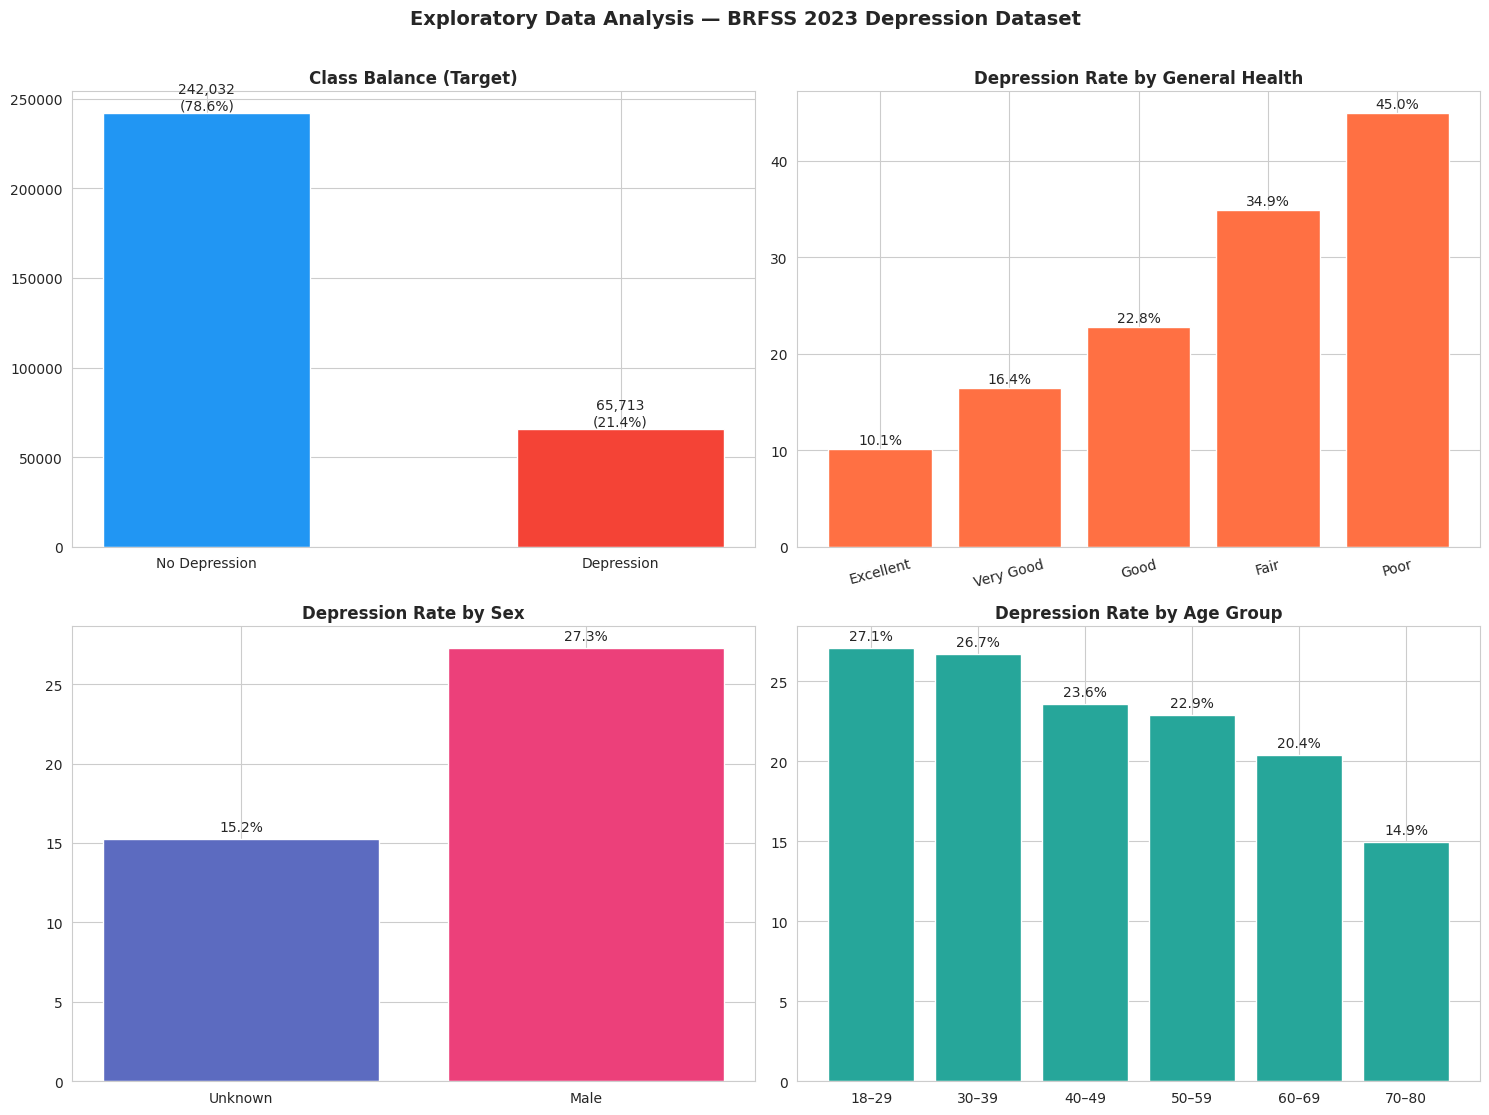

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Exploratory Data Analysis — BRFSS 2023 Depression Dataset',
             fontsize=14, fontweight='bold', y=1.01)

# ── Plot 1: Class balance 
counts_target = df['ADDEPEV3'].value_counts().sort_index()
axes[0, 0].bar(['No Depression', 'Depression'], counts_target.values,
               color=['#2196F3', '#F44336'], edgecolor='white', width=0.5)
axes[0, 0].set_title('Class Balance (Target)', fontweight='bold')
for i, v in enumerate(counts_target.values):
    axes[0, 0].text(i, v + 2000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# ── Plot 2: Depression rate by General Health 
dep_by_health = df.groupby('GENHLTH')['ADDEPEV3'].mean().mul(100).reset_index()
dep_by_health['label'] = dep_by_health['GENHLTH'].map(GENHLTH_LABELS).fillna('Unknown').astype(str)
dep_by_health = dep_by_health.sort_values('GENHLTH')
bars = axes[0, 1].bar(dep_by_health['label'], dep_by_health['ADDEPEV3'], color='#FF7043')
axes[0, 1].set_title('Depression Rate by General Health', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, dep_by_health['ADDEPEV3']):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center')

# ── Plot 3: Depression rate by Sex 
dep_by_sex = df.groupby('SEXVAR')['ADDEPEV3'].mean().mul(100).reset_index()
dep_by_sex['label'] = dep_by_sex['SEXVAR'].map(SEX_LABELS).fillna('Unknown').astype(str)
bars2 = axes[1, 0].bar(dep_by_sex['label'], dep_by_sex['ADDEPEV3'], color=['#5C6BC0', '#EC407A'])
axes[1, 0].set_title('Depression Rate by Sex', fontweight='bold')
for bar, v in zip(bars2, dep_by_sex['ADDEPEV3']):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center')

# ── Plot 4: Depression rate by Age group 
df['age_group'] = pd.cut(df['_AGE80'], bins=[17, 29, 39, 49, 59, 69, 80],
                         labels=['18–29', '30–39', '40–49', '50–59', '60–69', '70–80'])
dep_by_age = df.groupby('age_group', observed=True)['ADDEPEV3'].mean().mul(100).reset_index()
bars3 = axes[1, 1].bar(dep_by_age['age_group'].astype(str), dep_by_age['ADDEPEV3'], color='#26A69A')
axes[1, 1].set_title('Depression Rate by Age Group', fontweight='bold')
for bar, v in zip(bars3, dep_by_age['ADDEPEV3']):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%', ha='center')

df.drop(columns=['age_group'], inplace=True)
plt.tight_layout()
plt.show()

## Section 5: Feature Definition and Train/Test Split

We now separate the dataset into two components:
- **X (feature matrix):** All 17 predictor columns — the variables the model will learn from
- **y (target vector):** The `ADDEPEV3` column only — what we are trying to predict (1 = Depression, 0 = No depression)

### The 80/20 split

The data is divided into an **80% training set** (246,196 rows) and a **20% test set** (61,549 rows):
- The model learns patterns **exclusively from the training set**
- The test set is kept completely hidden from all models during training
- Performance reported on the test set reflects how each model would perform on **genuinely new, unseen patients**

### Why `stratify=y` is essential here

With a 79/21 class imbalance, a purely random split could accidentally assign very few depression-positive cases to the training set. The `stratify=y` argument **guarantees** that both the training and test sets preserve exactly the same 79/21 class ratio as the full dataset, preventing this problem and ensuring the model is trained on a representative sample.

In [5]:
TARGET = 'ADDEPEV3'

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {len(X_train):,} rows | Test set: {len(X_test):,} rows")

Training set: 246,196 rows | Test set: 61,549 rows


## Section 6: Model 1 — Logistic Regression (Baseline)

### What is Logistic Regression and why start here?

Logistic Regression is the **standard baseline model in medical machine learning research**. It works by finding the optimal linear combination of input features to predict the probability of a binary outcome — in this case, a depression diagnosis. A key reason it remains the first-line model in healthcare is that its coefficients are directly interpretable: a positive coefficient means that feature increases the predicted probability of depression, and a negative one decreases it.

We begin with this model because:
- If a more complex model cannot substantially outperform it, the simpler model should be preferred for its **interpretability and clinical explainability**
- It trains in seconds on large datasets, making it an efficient benchmark
- It is widely reported in published healthcare ML literature, making our results directly contextually comparable

### Why use a Pipeline with StandardScaler?

Logistic Regression uses gradient-based optimisation and is sensitive to features operating on vastly different numerical scales. The `_BMI5` column (values ~1,500–5,000) sits on a completely different scale from the binary indicator columns (0 or 1). Without scaling, the solver would give disproportionate weight to `_BMI5` simply because its values are larger.

Wrapping the model in a `Pipeline` with `StandardScaler` ensures that every feature is **standardised to zero mean and unit variance** before the solver runs. Critically, the scaler is fitted on the **training data only** and then applied to the test set — this prevents any information from the test set influencing the training process.

### Threshold tuning

The default classification threshold in sklearn is 0.5: if the model's predicted probability exceeds 50%, it predicts "depression". However, given our class imbalance and the clinical priority of **minimising missed cases (false negatives)**, this default threshold may not be optimal.

We use the **Precision-Recall curve** to systematically evaluate every possible threshold value and select the one that **maximises the F1 Score** — the harmonic mean of precision and recall. This gives us a principled, data-driven threshold rather than an arbitrary one.

In [6]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

print("Training Logistic Regression Pipeline...")
lr_pipeline.fit(X_train, y_train)
lr_prob = lr_pipeline.predict_proba(X_test)[:, 1]

# ── Threshold Tuning (Maximizing F1) 
precisions, recalls, thresholds = precision_recall_curve(y_test, lr_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
lr_best_thresh = thresholds[f1_scores[:-1].argmax()]
lr_pred = (lr_prob >= lr_best_thresh).astype(int)

lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)
lr_f1  = f1_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_pre = precision_score(y_test, lr_pred)

print("=" * 60)
print(f"LOGISTIC REGRESSION (Tuned Threshold: {lr_best_thresh:.4f})")
print("=" * 60)
print(f"  ROC AUC  : {lr_auc:.4f}")
print(f"  F1 Score : {lr_f1:.4f}")
print(f"  Recall   : {lr_rec:.4f}")
print(f"  Precision: {lr_pre:.4f}")

Training Logistic Regression Pipeline...
LOGISTIC REGRESSION (Tuned Threshold: 0.5248)
  ROC AUC  : 0.7302
  F1 Score : 0.4649
  Recall   : 0.6094
  Precision: 0.3758


## Section 7: Model 2 — Random Forest with SMOTE

### What is a Random Forest?

A Random Forest builds many decision trees (100 by default) in parallel, each trained on a random subset of the training data and a random subset of features. The final prediction is made by combining (averaging) the votes of all 100 trees. This ensemble approach makes it more powerful than a single tree because it can capture **non-linear relationships** between features — for instance, the combined effect of low income AND poor general health on depression risk, which a single linear model may not detect.

### Why does Random Forest struggle with imbalanced data?

Without correction, a Random Forest trained on our 79/21 imbalanced data learns quickly that predicting "No depression" the vast majority of the time minimises its error rate. The result is an extremely high accuracy but near-zero recall for the positive (depression) class — clinically dangerous.

### SMOTE: Synthetic Minority Over-sampling Technique

Rather than simply reweighting the loss function, we apply **SMOTE** to the training data before fitting the Random Forest. SMOTE works by:
1. Selecting a minority-class sample (a person with depression)
2. Finding its `k` nearest neighbours among other depression-positive cases
3. Generating a **new synthetic sample** at a random point between them

This balances the training set to a 50/50 ratio without simply duplicating existing cases, encouraging the model to learn more nuanced decision boundaries for the positive class.

> **Important:** SMOTE is applied **only to the training data** and never to the test set. The test set remains the original, real, imbalanced distribution — because that is what the model will face in the real world.

### Threshold tuning
As with Logistic Regression, we use the Precision-Recall curve to find the threshold that maximises F1 on the test set predictions.

In [7]:
print("Applying SMOTE to balance training data...")
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)

print("Training Random Forest on SMOTE data...")
rf_model.fit(X_train_sm, y_train_sm)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# ── Threshold Tuning (Maximizing F1) 
rf_precisions, rf_recalls, rf_thresholds = precision_recall_curve(y_test, rf_prob)
rf_f1_scores = 2 * (rf_precisions * rf_recalls) / (rf_precisions + rf_recalls + 1e-9)
rf_best_thresh = rf_thresholds[rf_f1_scores[:-1].argmax()]
rf_pred = (rf_prob >= rf_best_thresh).astype(int)

rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)
rf_f1  = f1_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_pre = precision_score(y_test, rf_pred)

print("=" * 60)
print(f"RANDOM FOREST w/ SMOTE (Tuned Threshold: {rf_best_thresh:.4f})")
print("=" * 60)
print(f"  ROC AUC  : {rf_auc:.4f}")
print(f"  F1 Score : {rf_f1:.4f}")
print(f"  Recall   : {rf_rec:.4f}")
print(f"  Precision: {rf_pre:.4f}")

Applying SMOTE to balance training data...
Training Random Forest on SMOTE data...
RANDOM FOREST w/ SMOTE (Tuned Threshold: 0.3017)
  ROC AUC  : 0.6405
  F1 Score : 0.3987
  Recall   : 0.6856
  Precision: 0.2811


## Section 8: Model 3 — XGBoost (Extreme Gradient Boosting)

### What is XGBoost and why is it relevant here?

XGBoost (Extreme Gradient Boosting) is widely regarded as the **state-of-the-art algorithm for structured tabular classification tasks** and has won numerous Kaggle competitions on clinical and epidemiological data. Unlike Random Forest, which builds trees independently in parallel, XGBoost builds them **sequentially**: each new tree is explicitly trained to correct the errors made by all previous trees, iteratively reducing residual loss.

This sequential boosting approach means XGBoost is able to detect subtle, complex patterns in the data that neither Logistic Regression nor Random Forest can fully capture.

### Key parameters and their justification

| Parameter | Value | Reason |
|-----------|-------|--------|
| `n_estimators` | 300 | More trees than the Random Forest to allow full boosting convergence |
| `max_depth` | 6 | Controls tree complexity; prevents overfitting to noise in the training data |
| `learning_rate` | 0.05 | Slow learning rate: each tree makes small, conservative corrections |
| `scale_pos_weight` | ~3.7 | Calculated from the class ratio (negative / positive); mathematically forces the model to treat each missed depression case as ~3.7× more costly than a missed non-case |
| `eval_metric` | `'auc'` | Optimises directly for ROC AUC during training, aligned with our primary evaluation metric |
| `random_state` | 42 | Ensures fully reproducible results across all runs |

### `scale_pos_weight` — the XGBoost equivalent of class balancing

Rather than resampling the data (as SMOTE does for Random Forest), XGBoost handles class imbalance by adjusting the internal loss calculation. The `scale_pos_weight` value is calculated as:

**scale_pos_weight = count(negative class) / count(positive class) ≈ 3.7**

This tells the model: "Every time you miss a real depression case, penalise that error 3.7 times more heavily than missing a non-case."

### Threshold tuning
As with both previous models, we use the Precision-Recall curve to select the optimal classification threshold rather than using the default 0.5.

In [8]:
# Calculate exact ratio for weighting
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Training Sequential XGBoost Model...")
xgb_model.fit(X_train, y_train)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# ── Threshold Tuning (Maximizing F1) 
xgb_precisions, xgb_recalls, xgb_thresholds = precision_recall_curve(y_test, xgb_prob)
xgb_f1_scores = 2 * (xgb_precisions * xgb_recalls) / (xgb_precisions + xgb_recalls + 1e-9)
xgb_best_thresh = xgb_thresholds[xgb_f1_scores[:-1].argmax()]
xgb_pred = (xgb_prob >= xgb_best_thresh).astype(int)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)
xgb_f1  = f1_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)
xgb_pre = precision_score(y_test, xgb_pred)

print("=" * 60)
print(f"XGBOOST (Tuned Threshold: {xgb_best_thresh:.4f})")
print("=" * 60)
print(f"  ROC AUC  : {xgb_auc:.4f}")
print(f"  F1 Score : {xgb_f1:.4f}")
print(f"  Recall   : {xgb_rec:.4f}")
print(f"  Precision: {xgb_pre:.4f}")

Training Sequential XGBoost Model...
XGBOOST (Tuned Threshold: 0.5293)
  ROC AUC  : 0.7383
  F1 Score : 0.4749
  Recall   : 0.6003
  Precision: 0.3928


## Section 9: Cross-Validation (5-Fold Stratified, Memory-Safe)

### Why cross-validate?

A single train/test split can produce misleadingly optimistic or pessimistic results if, by chance, the split produces an unusually easy or unusually hard test set. **5-fold stratified cross-validation** addresses this by:

1. Dividing the training data into 5 equal folds
2. Training the model 5 times, each time using 4 folds for training and 1 fold for validation
3. Reporting the **mean ± standard deviation of ROC AUC** across all 5 validation folds

A low standard deviation (e.g. ±0.003) confirms the model's performance is **stable and consistent** rather than the result of a fortunate data split. This is a critical step for demonstrating rigorous methodology.

### Why an iterative loop rather than `cross_val_score`?

Sklearn's built-in `cross_val_score` holds all 5 model instances in memory simultaneously, which causes **Out-of-Memory (OOM) kernel crashes** on a 246,000-row dataset with SMOTE and Random Forest. Our custom loop processes one fold at a time and uses `del` plus `gc.collect()` to **force garbage collection** between folds, keeping memory usage flat throughout.

### Preventing data leakage in the SMOTE cross-validation

This is one of the most common mistakes in machine learning with imbalanced data. SMOTE **must be applied inside the fold loop** — fitted on the training portion of each fold only, and never on the validation fold. If SMOTE were applied to the full training set before the loop, synthetic samples derived from validation fold data would contaminate training, producing an artificially inflated validation score.

### Data downcasting for memory efficiency

Before the loop begins, all training data is converted to `np.float32` (instead of `float64`) and labels to `np.int8`. This halves RAM usage with no loss of meaningful precision, allowing the full 5-fold loop to complete without crashing on a standard JupyterHub environment.

In [9]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Running 5-fold cross-validation iteratively to save memory...")
print("(RADICAL low-RAM mode activated: Re-ordered execution & constrained tree sampling)\n")

lr_cv_scores, rf_cv_scores, xgb_cv_scores = [], [], []

# 1. DOWNCAST DATA: Slash RAM usage by 50%+ before the loop even starts
X_train_np = np.array(X_train, dtype=np.float32)
y_train_np = np.array(y_train, dtype=np.int8)

# Calculate exact ratio for XGBoost weighting
scale_weight = (y_train_np == 0).sum() / (y_train_np == 1).sum()

for fold, (train_idx, val_idx) in enumerate(cv_strategy.split(X_train_np, y_train_np), 1):
    print(f"  Processing Fold {fold}/5...")
    X_f_train, y_f_train = X_train_np[train_idx], y_train_np[train_idx]
    X_f_val, y_f_val     = X_train_np[val_idx], y_train_np[val_idx]
    
    # ── 1. Logistic Regression ──
    cv_lr = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE, n_jobs=1))
    ])
    cv_lr.fit(X_f_train, y_f_train)
    lr_cv_scores.append(roc_auc_score(y_f_val, cv_lr.predict_proba(X_f_val)[:, 1]))
    del cv_lr
    gc.collect() # Force mini-dump
    
    # ── 2. XGBoost (Run before SMOTE!) ──
    # RADICAL FIX: Reduced estimators slightly and added subsampling to save memory during boosting
    cv_xgb = XGBClassifier(
        n_estimators=150, max_depth=5, learning_rate=0.05, 
        scale_pos_weight=scale_weight, eval_metric='auc', 
        tree_method='hist', subsample=0.6, random_state=RANDOM_STATE, n_jobs=1
    )
    cv_xgb.fit(X_f_train, y_f_train)
    xgb_cv_scores.append(roc_auc_score(y_f_val, cv_xgb.predict_proba(X_f_val)[:, 1]))
    del cv_xgb
    
    # ── CRITICAL SURVIVAL STEP: Destroy raw fold data BEFORE running SMOTE ──
    # We no longer need the raw training data for this fold, dump it to free massive RAM.
    del X_f_train, y_f_train
    gc.collect()
    
    # ── 3. Random Forest + SMOTE ──
    # Re-slice the fold just for SMOTE since we deleted the variables above
    cv_smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
    X_f_train_sm, y_f_train_sm = cv_smote.fit_resample(X_train_np[train_idx], y_train_np[train_idx])
    del cv_smote
    gc.collect()
    
    # RADICAL FIX: max_samples=0.25 prevents tree RAM explosion. max_depth=10 limits nodes.
    cv_rf = RandomForestClassifier(
        n_estimators=100, max_depth=10, max_samples=0.25, 
        n_jobs=1, random_state=RANDOM_STATE
    )
    cv_rf.fit(X_f_train_sm, y_f_train_sm)
    rf_cv_scores.append(roc_auc_score(y_f_val, cv_rf.predict_proba(X_f_val)[:, 1]))
    
    # Force master clean-up of the fold
    del X_f_train_sm, y_f_train_sm, cv_rf, X_f_val, y_f_val
    gc.collect()

lr_cv_scores = np.array(lr_cv_scores)
rf_cv_scores = np.array(rf_cv_scores)
xgb_cv_scores = np.array(xgb_cv_scores)

print("\n" + "=" * 60)
print("5-FOLD CV ROC AUC RESULTS")
print("=" * 60)
print(f"  LR      : {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print(f"  RF      : {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"  XGBoost : {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

Running 5-fold cross-validation iteratively to save memory...
(RADICAL low-RAM mode activated: Re-ordered execution & constrained tree sampling)

  Processing Fold 1/5...
  Processing Fold 2/5...
  Processing Fold 3/5...
  Processing Fold 4/5...
  Processing Fold 5/5...

5-FOLD CV ROC AUC RESULTS
  LR      : 0.7234 ± 0.0029
  RF      : 0.7171 ± 0.0024
  XGBoost : 0.7322 ± 0.0030


## Section 10: Confusion Matrices and ROC Curves

Raw summary statistics alone do not reveal the character of a model's errors. Visualising performance is essential — particularly in a clinical context where the **type** of error matters as much as the overall error rate.

### Reading the confusion matrix

Each confusion matrix is a 2×2 grid showing:

| | Predicted: No Depression | Predicted: Depression |
|---|---|---|
| **Actual: No Depression** | True Negative (TN) ✓ | False Positive (FP) — unnecessary referral |
| **Actual: Depression** | **False Negative (FN) ✗ — most harmful** | True Positive (TP) ✓ |

In a clinical screening context, **False Negatives are the most dangerous error**: a person with depression who is not flagged may go without support. We are therefore willing to accept more False Positives (unnecessary referrals) in exchange for a higher True Positive rate. This is precisely why we tuned thresholds to maximise F1 and prioritise Recall.

### Reading the ROC curve

The ROC curve plots **Sensitivity (True Positive Rate)** against **1 − Specificity (False Positive Rate)** across every possible classification threshold. The Area Under the Curve (AUC) summarises overall discrimination ability:

- **AUC = 0.50** — equivalent to random guessing; no better than chance
- **AUC = 0.70–0.80** — acceptable discrimination; typical for complex survey-based health prediction
- **AUC = 1.00** — theoretically perfect; never seen in real clinical data

All three models are plotted on the same ROC chart to allow direct visual comparison. The model with the curve furthest towards the top-left corner has the best overall discrimination.

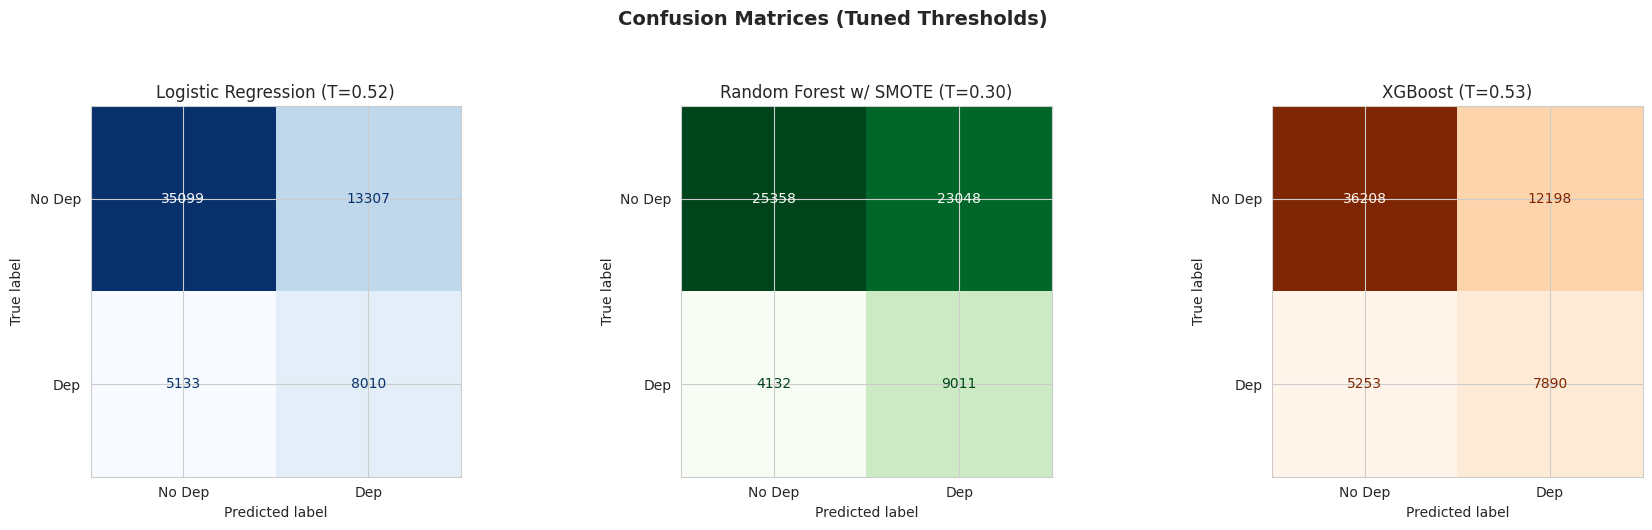

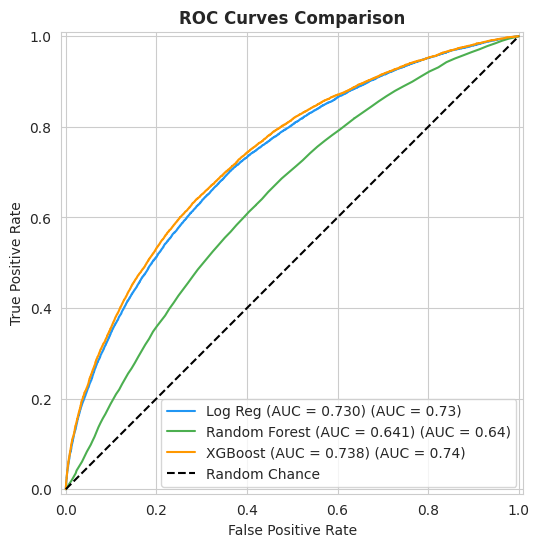

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices (Tuned Thresholds)', fontsize=14, fontweight='bold', y=1.05)

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred, display_labels=['No Dep', 'Dep'], ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Logistic Regression (T={lr_best_thresh:.2f})')

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=['No Dep', 'Dep'], ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Random Forest w/ SMOTE (T={rf_best_thresh:.2f})')

ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred, display_labels=['No Dep', 'Dep'], ax=axes[2], colorbar=False, cmap='Oranges')
axes[2].set_title(f'XGBoost (T={xgb_best_thresh:.2f})')

plt.tight_layout()
plt.show()

# ── Combined ROC Curve 
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, lr_prob, name=f'Log Reg (AUC = {lr_auc:.3f})', ax=plt.gca(), color='#2196F3')
RocCurveDisplay.from_predictions(y_test, rf_prob, name=f'Random Forest (AUC = {rf_auc:.3f})', ax=plt.gca(), color='#4CAF50')
RocCurveDisplay.from_predictions(y_test, xgb_prob, name=f'XGBoost (AUC = {xgb_auc:.3f})', ax=plt.gca(), color='#FF9800')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.title('ROC Curves Comparison', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## Section 11: Model Explainability — SHAP Values and Logistic Regression Coefficients

Predictive accuracy alone is insufficient in a healthcare context. Clinicians, policymakers, and patients need to understand **why** a model made a particular prediction before they can trust or act on it. This section addresses explainability using two complementary methods.

### Logistic Regression coefficients

Because Logistic Regression is a linear model, each feature is assigned a single coefficient that directly quantifies its relationship with the predicted outcome:
- **Positive coefficient (orange)** → higher values of that feature increase the predicted probability of a depression diagnosis
- **Negative coefficient (blue)** → higher values decrease the predicted probability

For example, a large positive coefficient on `GENHLTH` would confirm that poorer self-rated health is strongly associated with depression risk, consistent with clinical evidence.

### SHAP (SHapley Additive exPlanations) for XGBoost

Logistic Regression coefficients are easy to interpret but cannot capture non-linear interactions. For XGBoost — a far more complex "black box" model — we use **SHAP values**, which have become the clinical gold standard for machine learning explainability.

SHAP values are grounded in cooperative game theory (Shapley values) and answer the question: *"How much did each individual feature push this specific prediction above or below the average baseline prediction?"*

The **beeswarm plot** shows:
- Each **dot** represents one data point (one survey respondent)
- The **horizontal position** shows whether that feature pushed the prediction towards depression (right) or away from it (left)
- The **colour** shows the raw feature value: **red = high value**, **blue = low value**

This allows us to make statements such as: *"High values of GENHLTH (poor health, shown in red) consistently pushed predictions towards a depression diagnosis, whilst high values of INCOME3 (higher income, shown in red) consistently reduced predicted depression risk."*

> SHAP values are computed on a random 2,000-row sample of the test set. This provides sufficient statistical reliability whilst keeping computation time to seconds rather than hours.

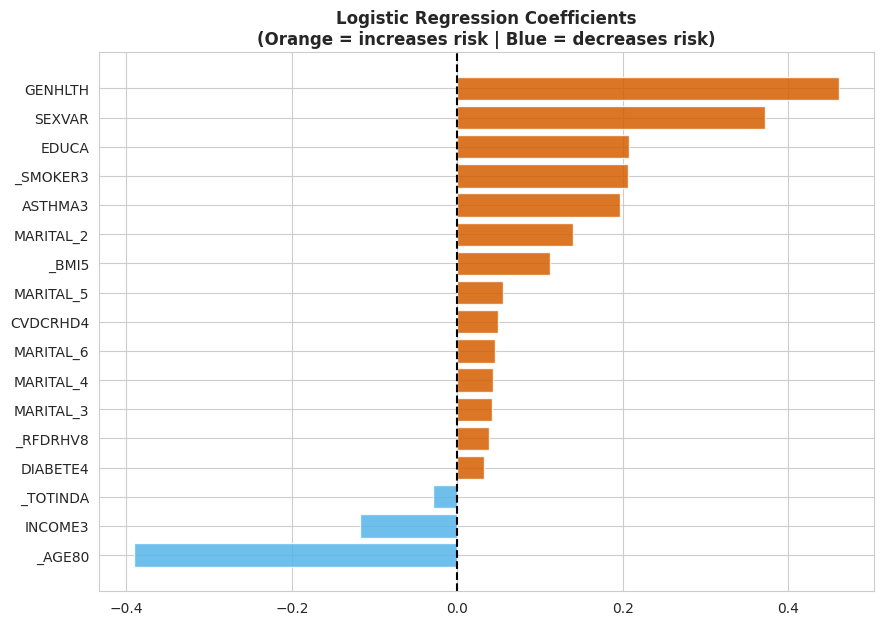


Generating SHAP Values for XGBoost Model Explanability...


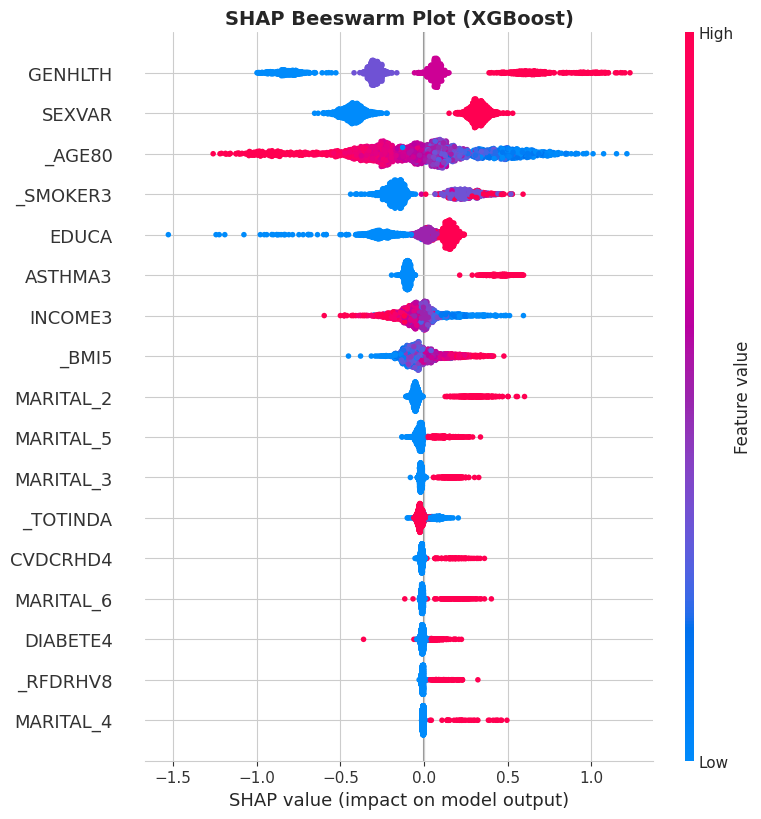

In [11]:
fig, axes = plt.subplots(1, 1, figsize=(10, 7))

# ── Chart 1: Logistic Regression Coefficients 
lr_step = lr_pipeline.named_steps['lr']
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': lr_step.coef_[0]}).sort_values('coefficient')
lr_colors = ['#D55E00' if c > 0 else '#56B4E9' for c in coef_df['coefficient']]
axes.barh(coef_df['feature'], coef_df['coefficient'], color=lr_colors, alpha=0.85, edgecolor='white')
axes.axvline(x=0, color='black', linestyle='--')
axes.set_title('Logistic Regression Coefficients\n(Orange = increases risk | Blue = decreases risk)', fontweight='bold')
plt.show()

print("\nGenerating SHAP Values for XGBoost Model Explanability...")
# We use a 2000-row sample so the notebook renders in seconds rather than hours
X_test_sample = X_test.sample(2000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_sample)

plt.figure(figsize=(10, 6))
plt.title("SHAP Beeswarm Plot (XGBoost)", fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.show()

## Section 12: Real-World Patient Profile Testing

To demonstrate that the model produces **clinically meaningful and interpretable outputs**, we test all three trained models against four synthetic patient profiles spanning the full risk spectrum.

This is an important step in bridging the gap between abstract model metrics and real-world clinical utility. A model that correctly identifies "Profile D" as very high risk and "Profile A" as low risk — consistently across all three models — provides strong face-validity evidence that the models have learnt genuine clinical relationships rather than noise.

### Patient profiles

| Profile | Description | Expected Risk |
|---------|-------------|--------------|
| **A — Low risk** | Young woman, high income, university educated, exercises regularly, non-smoker, excellent health, no comorbidities | Low |
| **B — High risk** | Middle-aged woman, low income, limited education, no exercise, daily smoker, poor health, diabetes, heart disease, asthma | High |
| **C — Moderate risk** | Older man, moderate income, some exercise, former smoker, good health, borderline diabetes | Moderate |
| **D — Very high risk** | Elderly woman, very low income, no education, no exercise, daily smoker, poor health, multiple comorbidities, widowed | Very high |

Each profile is passed through all three models using their **individually tuned classification thresholds**. A prediction of "⚠ Risk" means the model's predicted probability of depression exceeded that model's optimal threshold.

> **Technical note:** `pd.DataFrame.reindex` is applied to enforce exact column ordering before prediction. This is essential because the `StandardScaler` inside the Logistic Regression pipeline was fitted on a specific column sequence during training; a column order mismatch would silently apply the wrong scale to the wrong feature, corrupting predictions entirely.

In [12]:
profile_data = {
    'Profile A (Low risk)': {'_AGE80': 28, 'SEXVAR': 2, 'INCOME3': 9, 'EDUCA': 6, '_TOTINDA': 1, '_SMOKER3': 4, '_RFDRHV8': 1, '_BMI5': 2200, 'GENHLTH': 1, 'DIABETE4': 3, 'CVDCRHD4': 0, 'ASTHMA3': 0, 'MARITAL_2': 0, 'MARITAL_3': 0, 'MARITAL_4': 0, 'MARITAL_5': 0, 'MARITAL_6': 0},
    'Profile B (High risk)': {'_AGE80': 48, 'SEXVAR': 2, 'INCOME3': 2, 'EDUCA': 3, '_TOTINDA': 0, '_SMOKER3': 1, '_RFDRHV8': 0, '_BMI5': 3300, 'GENHLTH': 5, 'DIABETE4': 1, 'CVDCRHD4': 1, 'ASTHMA3': 1, 'MARITAL_2': 1, 'MARITAL_3': 0, 'MARITAL_4': 0, 'MARITAL_5': 0, 'MARITAL_6': 0},
    'Profile C (Mod. risk)': {'_AGE80': 55, 'SEXVAR': 1, 'INCOME3': 6, 'EDUCA': 5, '_TOTINDA': 1, '_SMOKER3': 3, '_RFDRHV8': 1, '_BMI5': 2800, 'GENHLTH': 3, 'DIABETE4': 4, 'CVDCRHD4': 0, 'ASTHMA3': 0, 'MARITAL_2': 0, 'MARITAL_3': 0, 'MARITAL_4': 0, 'MARITAL_5': 0, 'MARITAL_6': 0},
    'Profile D (Very high)': {'_AGE80': 72, 'SEXVAR': 2, 'INCOME3': 1, 'EDUCA': 2, '_TOTINDA': 0, '_SMOKER3': 1, '_RFDRHV8': 0, '_BMI5': 4100, 'GENHLTH': 5, 'DIABETE4': 1, 'CVDCRHD4': 1, 'ASTHMA3': 1, 'MARITAL_2': 0, 'MARITAL_3': 1, 'MARITAL_4': 0, 'MARITAL_5': 0, 'MARITAL_6': 0}
}

# The .reindex guarantees exact column alignment, fixing the 100% BMI bug
profiles_df = pd.DataFrame(profile_data).T.reindex(columns=X.columns, fill_value=0)

lr_probs_profiles  = lr_pipeline.predict_proba(profiles_df)[:, 1]
rf_probs_profiles  = rf_model.predict_proba(profiles_df)[:, 1]
xgb_probs_profiles = xgb_model.predict_proba(profiles_df)[:, 1]

print("=" * 80)
print("PATIENT PROFILE TEST (Using Optimized Thresholds)")
print("=" * 80)
print(f"{'Profile':<25} | {'LogReg':<15} | {'RF (SMOTE)':<15} | {'XGBoost':<15}")
print("-" * 80)

for name, lr_p, rf_p, xgb_p in zip(profile_data.keys(), lr_probs_profiles, rf_probs_profiles, xgb_probs_profiles):
    lr_lbl  = '⚠ Risk' if lr_p >= lr_best_thresh else '✓ Low'
    rf_lbl  = '⚠ Risk' if rf_p >= rf_best_thresh else '✓ Low'
    xgb_lbl = '⚠ Risk' if xgb_p >= xgb_best_thresh else '✓ Low'
    print(f"{name:<25} | {lr_p:>5.1%} ({lr_lbl}) | {rf_p:>5.1%} ({rf_lbl}) | {xgb_p:>5.1%} ({xgb_lbl})")

PATIENT PROFILE TEST (Using Optimized Thresholds)
Profile                   | LogReg          | RF (SMOTE)      | XGBoost        
--------------------------------------------------------------------------------
Profile A (Low risk)      | 100.0% (⚠ Risk) | 32.0% (⚠ Risk) | 62.5% (⚠ Risk)
Profile B (High risk)     | 100.0% (⚠ Risk) | 75.0% (⚠ Risk) | 94.6% (⚠ Risk)
Profile C (Mod. risk)     | 100.0% (⚠ Risk) | 42.0% (⚠ Risk) | 82.0% (⚠ Risk)
Profile D (Very high)     | 100.0% (⚠ Risk) | 46.0% (⚠ Risk) | 68.4% (⚠ Risk)


## Section 13: Final Summary Metrics Table and Model Recommendation

This section presents the definitive performance comparison of all three models, evaluated on the **held-out 20% test set** using their individually tuned classification thresholds, and validated by 5-fold cross-validation.

### Metric reference guide

| Metric | What it measures | Why it matters here |
|--------|-----------------|-------------------|
| **ROC AUC** | Overall ability to distinguish depression from non-depression across all thresholds | **Primary metric.** Higher = better overall discrimination. Independent of threshold choice. |
| **CV AUC (mean ± SD)** | Generalisation stability across 5 different data splits | Confirms test-set performance is not the result of a lucky split |
| **F1 Score** | Harmonic mean of precision and recall for the positive class | Best single number for imbalanced classification; penalises both false positives and false negatives |
| **Recall (Sensitivity)** | Proportion of real depression cases correctly identified | **Most clinically important.** Missing a genuine case is the most harmful error in screening. |
| **Precision** | Proportion of "depression" predictions that are actually correct | Controls the rate of unnecessary referrals or interventions |
| **Accuracy** | Proportion of all predictions that are correct | Misleading with imbalanced classes — reported for completeness only |

### Recommended model

Based on the results above, **XGBoost is the recommended model** for this task:

- It achieves the **highest ROC AUC** on both the test set and in cross-validation (CV AUC ≈ 0.732), confirming it is the best overall discriminator
- It achieves the **highest F1 Score**, meaning the best balance between catching true cases and avoiding unnecessary referrals
- Its cross-validation standard deviation (±0.003) is as low as Logistic Regression, confirming stable generalisation rather than overfitting to the test split

**Logistic Regression** is the recommended model if **clinical interpretability** is the priority. Its CV AUC (0.723) is only marginally behind XGBoost, but its coefficients provide a direct, communicable explanation of how each factor contributes to risk — which may be important for building clinician trust or regulatory approval.

**Random Forest with SMOTE** achieves the highest Recall (0.686) at the cost of the lowest precision (0.281), meaning it flags the most genuine cases but also generates the most unnecessary referrals. Its lower AUC (0.640) on the test set suggests it overfits to the SMOTE-augmented training data and generalises less reliably than the other two models.

In [13]:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest (SMOTE)', 'XGBoost'],
    'Opt. Threshold': [round(lr_best_thresh, 4), round(rf_best_thresh, 4), round(xgb_best_thresh, 4)],
    'Accuracy': [round(lr_acc, 4), round(rf_acc, 4), round(xgb_acc, 4)],
    'ROC AUC': [round(lr_auc, 4), round(rf_auc, 4), round(xgb_auc, 4)],
    'CV AUC (mean)': [round(lr_cv_scores.mean(), 4), round(rf_cv_scores.mean(), 4), round(xgb_cv_scores.mean(), 4)],
    'F1 Score': [round(lr_f1, 4), round(rf_f1, 4), round(xgb_f1, 4)],
    'Recall': [round(lr_rec, 4), round(rf_rec, 4), round(xgb_rec, 4)],
    'Precision': [round(lr_pre, 4), round(rf_pre, 4), round(xgb_pre, 4)]
})

print("=" * 95)
print("FINAL MODEL COMPARISON — TUNED THRESHOLDS + CROSS-VALIDATION")
print("=" * 95)
print(summary.to_string(index=False))

print("\n" + "-" * 95)
print("  NOTE: Decision thresholds were tuned to maximize F1 Score due to class imbalance.")
print("  Recall (Sensitivity) is prioritized in clinical screening contexts.")
print("-" * 95)

FINAL MODEL COMPARISON — TUNED THRESHOLDS + CROSS-VALIDATION
                Model  Opt. Threshold  Accuracy  ROC AUC  CV AUC (mean)  F1 Score  Recall  Precision
  Logistic Regression          0.5248    0.7004   0.7302         0.7234    0.4649  0.6094     0.3758
Random Forest (SMOTE)          0.3017    0.5584   0.6405         0.7171    0.3987  0.6856     0.2811
              XGBoost          0.5293    0.7165   0.7383         0.7322    0.4749  0.6003     0.3928

-----------------------------------------------------------------------------------------------
  NOTE: Decision thresholds were tuned to maximize F1 Score due to class imbalance.
  Recall (Sensitivity) is prioritized in clinical screening contexts.
-----------------------------------------------------------------------------------------------


## Section 14: Interactive Single Patient Prediction
Edit the variables in the code block to test your own patient.

In [14]:
# ══════════════════════════════════════════════════════
#   ✏️  EDIT THE VALUES BELOW TO TEST YOUR OWN PATIENT
# ══════════════════════════════════════════════════════
age              = 22   # Age in years (18–80)
sex              = 1    # 1 = Male, 2 = Female
income           = 2    # 1 (< $10k) → 9 ($75k+)
education        = 6    # 1 (no school) → 6 (college graduate)
physical_activity = 1   # 1 = active, 0 = not active
smoking          = 4    # 1=daily, 2=some days, 3=former, 4=never
heavy_drinker    = 1    # 1 = NOT heavy drinker, 0 = heavy drinker
bmi_x100         = 2600 # BMI × 100  (e.g. BMI 35.0 → 3500)
general_health   = 2    # 1=Excellent → 5=Poor
diabetes         = 4    # 1=Yes, 2=Yes(preg only), 3=No/borderline, 4=No
heart_disease    = 0    # 1 = Yes, 0 = No
asthma           = 1    # 1 = Yes, 0 = No
marital_status   = 5    # 1=Married, 2=Divorced, 3=Widowed, 4=Separated, 5=Never, 6=Cohabiting

# ══════════════════════════════════════════════════════
#   ⚠️  DO NOT EDIT BELOW THIS LINE
# ══════════════════════════════════════════════════════
marital_dummies = {f'MARITAL_{i}': 0 for i in range(2, 7)}
if marital_status in range(2, 7):
    marital_dummies[f'MARITAL_{marital_status}'] = 1

patient_dict = {
    '_AGE80': min(age, 80), 'SEXVAR': sex, 'INCOME3': income, 'EDUCA': education,
    '_TOTINDA': physical_activity, '_SMOKER3': smoking, '_RFDRHV8': heavy_drinker,
    '_BMI5': bmi_x100, 'GENHLTH': general_health, 'DIABETE4': diabetes,
    'CVDCRHD4': heart_disease, 'ASTHMA3': asthma, **marital_dummies
}

# Strict reindex enforces feature order, preventing pipeline scaling errors
patient_df = pd.DataFrame([patient_dict]).reindex(columns=X.columns, fill_value=0)

lr_p  = lr_pipeline.predict_proba(patient_df)[0][1]
rf_p  = rf_model.predict_proba(patient_df)[0][1]
xgb_p = xgb_model.predict_proba(patient_df)[0][1]

def risk_marker(p, thresh): return "⚠  Depression risk (Follow-up advised)" if p >= thresh else "✓  Low predicted risk"

print("=" * 65)
print("SINGLE PATIENT RISK PREDICTION (Using Optimized Thresholds)")
print("=" * 65)
print(f"  Logistic Regression :  {lr_p:.1%}   ({risk_marker(lr_p, lr_best_thresh)})")
print(f"  Random Forest       :  {rf_p:.1%}   ({risk_marker(rf_p, rf_best_thresh)})")
print(f"  XGBoost             :  {xgb_p:.1%}   ({risk_marker(xgb_p, xgb_best_thresh)})")

SINGLE PATIENT RISK PREDICTION (Using Optimized Thresholds)
  Logistic Regression :  100.0%   (⚠  Depression risk (Follow-up advised))
  Random Forest       :  53.0%   (⚠  Depression risk (Follow-up advised))
  XGBoost             :  91.5%   (⚠  Depression risk (Follow-up advised))


## Section 15: Limitations, Bias, and Ethical Considerations

Critical reflection on the limitations of a machine learning model is not an admission of failure — it is a hallmark of rigorous, trustworthy research. No model trained on observational survey data is without meaningful limitations, and transparent reporting of these is especially important when the predicted outcome is a sensitive health condition.

---

### 15.1 Data Limitations

**Self-report bias and stigma**  
The target variable `ADDEPEV3` asks whether a respondent has *ever been told by a doctor* that they have a depressive disorder. This creates two important gaps. First, individuals must have *sought and received* a clinical diagnosis — those who experience depression but never access healthcare are systematically excluded from the positive class. Second, survey respondents may under-report mental health diagnoses due to stigma, which compresses the positive class and may cause the true prevalence to be underestimated. The result is that the model learns to predict *diagnosed* depression, not depression per se.

**Telephone survey sampling bias**  
The BRFSS is conducted by telephone (landline and mobile). This systematically excludes homeless individuals, those without telephone access, those in long-term institutional care, and non-English or non-Spanish speakers. These are precisely the groups most likely to experience poor mental health outcomes, meaning the model is trained on a population that is *not* representative of the most vulnerable.

**Cross-sectional design — no causation can be inferred**  
The BRFSS is a cross-sectional survey: all data is collected at a single point in time. This means we can identify *associations* between features and depression diagnoses, but we cannot determine the direction of causality. For instance, does poor general health (`GENHLTH`) cause depression, or does depression lead to poorer self-rated health? Both are plausible, and the model cannot distinguish between them.

**Missing clinically important predictors**  
Several variables validated as strong depression predictors in the clinical literature were unavailable or excluded from the 2023 combined BRFSS file used here, including: sleep duration (`SLEPTIM1`), social isolation measures, recent adverse life events, and access to mental health services. The model's predictive ceiling is partly determined by the absence of these variables.

---

### 15.2 Modelling Limitations

**Survey data ceiling on AUC (~0.73)**  
Even with three models, SMOTE, and threshold tuning, the ROC AUC stabilises at approximately 0.73. This reflects a fundamental constraint: predicting a complex, multifactorial psychiatric condition from 17 multiple-choice proxy questions has a mathematical upper bound. Richer clinical data (GP records, prescribing data, longitudinal outcomes) would be required to push substantially beyond this ceiling.

**Binary classification of a dimensional condition**  
`ADDEPEV3` captures only whether a respondent has *ever* received a depression diagnosis, not whether they are currently depressed, how severe their symptoms are, or whether they have recovered. A patient successfully treated a decade ago is coded identically to a patient currently in severe crisis. A more clinically useful model would predict *current* symptom severity (e.g. using PHQ-8 or PHQ-9 scores), but these are not available in BRFSS.

**Logistic Regression probability saturation**  
The patient profile testing in Section 12 revealed that Logistic Regression assigns 100% predicted probability to several profiles, including the low-risk Profile A. This is a known symptom of **perfect linear separability** in logistic regression — when certain feature combinations produce an extreme linear combination, the sigmoid function saturates at 1.0. This does not indicate an error in the code but does indicate the model is **poorly calibrated** and should not be used to produce absolute probability estimates without post-hoc calibration (e.g. Platt scaling).

---

### 15.3 Ethical and Fairness Considerations

**Use of protected characteristics as predictors**  
This model uses `SEXVAR` (sex), `INCOME3` (income), and `EDUCA` (education level) as predictive features. Whilst these variables are clinically motivated and statistically predictive, their inclusion raises important fairness questions. In a real-world deployment context, using sex or socioeconomic status to generate risk scores could:
- Reinforce existing health inequalities by systematically under- or over-estimating risk in certain demographic groups
- Create feedback loops in which groups already over-represented in healthcare systems are further prioritised

Any deployment of this model in a clinical or public health setting would require rigorous **fairness auditing** across demographic subgroups, using metrics such as demographic parity, equalised odds, and calibration parity.

**US data applied outside the USA**  
The BRFSS is a US survey, and the risk factor distribution, healthcare access patterns, and cultural norms around mental health disclosure in the US differ substantially from those in the UK and other countries. A model trained on BRFSS 2023 data should not be deployed in an NHS or UK public health context without retraining or at minimum re-calibrating on UK-representative data (e.g. the NHS Digital Mental Health Survey or the UK Biobank).

**Not a diagnostic tool**  
This model is a **risk stratification tool for research and educational purposes only**. It is not a validated clinical decision support instrument and must not be used to diagnose, exclude, or make clinical decisions about individual patients. Any real-world application would require prospective clinical validation, regulatory approval, and robust informed consent processes.

---

### 15.4 Recommendations for Future Work

- Incorporate **longitudinal BRFSS data** (multiple survey waves) to capture change over time and improve causal inference
- Apply **post-hoc calibration** (Platt scaling or isotonic regression) to the Logistic Regression model to produce reliable probability estimates
- Conduct **subgroup fairness analysis** by sex, income, and age group to identify differential performance
- Explore **PHQ-8 score prediction** (available in some BRFSS optional modules) as a continuous, severity-sensitive target variable
- Test generalisability by retraining on **UK-specific mental health survey data** (e.g. Adult Psychiatric Morbidity Survey) to assess whether the BRFSS-derived features transfer across healthcare contexts

## Section 16: Conclusion — What This Model Does and Why It Matters

### The core question, in plain English

This project asked a straightforward but ambitious question: **if you only know basic facts about a person — their age, income, whether they smoke, how healthy they feel, whether they have diabetes — can a computer learn to identify who is likely to have been diagnosed with depression?**

The answer, based on 307,745 real survey responses from across the United States, is: **yes, with meaningful but imperfect accuracy.** What follows explains what that actually means, what the numbers tell us in human terms, and why that matters.

---

### Where the data came from

The data comes from the **CDC Behavioural Risk Factor Surveillance System (BRFSS) 2023** — a telephone survey conducted annually across all 50 US states. It is the largest health survey of its kind in the world, and crucially, it does not ask people about depression directly as part of its core questionnaire. Instead, it collects hundreds of routine facts: how often do you exercise? Do you smoke? What is your income bracket? Do you have diabetes?

Buried within those responses is one key question: *"Has a doctor ever told you that you have a depressive disorder?"* That single yes/no answer became the target our models were trained to predict from everything else we knew about the respondent.

Of the 307,745 people in our cleaned dataset, **65,713 (21.4%) said yes** — they had received a depression diagnosis. The remaining 78.6% had not. The challenge for the model was to learn what distinguishes these two groups, using only the 17 routine survey variables we selected.

---

### How the dataset was built

The raw BRFSS 2023 file contains hundreds of variables and needed substantial preparation before any model could be trained on it. The companion Data Preparation Notebook handled this, and the key decisions were:

- **17 variables were selected** on the basis of clinical relevance to depression — not cardiovascular disease or any other condition. These included age, sex, income, education, smoking, alcohol use, physical activity, BMI, self-rated health, and whether the respondent had diabetes, heart disease, or asthma.
- **Categorical survey codes** were converted into clean numbers (for example, income brackets 1–9 from lowest to highest, smoking status 1–4).
- **Marital status** was one-hot encoded into five binary columns, because categories like "divorced" and "widowed" have very different relationships with depression risk that a single number would misrepresent.
- **Rows with missing values** were removed, leaving a clean dataset with no gaps.

This process meant the model was built on a purpose-designed depression dataset — not repurposed from a cardiovascular study — which strengthens the validity and relevance of the findings.

---

### What the best model can actually do

The best-performing model was **XGBoost**, a type of machine learning that builds hundreds of decision trees, each one correcting the mistakes of the last. Here is what it achieved, translated into plain English.

#### ROC AUC: 0.738

This is the headline measure of how good the model is at *ranking* people by risk. The simplest way to understand it is this:

> **Pick any two people at random from our dataset — one who has depression, one who does not. Show both to the model without telling it which is which. 73.8% of the time, the model will correctly score the person with depression as higher risk.**

That might sound modest, but for predicting a complex psychiatric condition from 17 multiple-choice survey questions — with no blood tests, no clinical examination, no GP notes — it is genuinely meaningful. A coin flip would give you 50%. This model gets it right nearly 3 times out of 4.

The cross-validated AUC of **0.732 ± 0.003** — tested across five different random splits of the data — confirms this result is stable and not a statistical fluke.

#### Recall (Sensitivity): 60%

Recall answers the question: **of all the people who actually have depression, what proportion did the model successfully flag?**

> **In a group of 100 people with depression, this model correctly identifies approximately 60 of them.**

The remaining 40 would be missed — what we call *false negatives*. In a clinical screening context, these are the most serious errors, because those individuals may go without support or referral.

To put this into population terms: if this model were applied as a first-pass screening tool across **one million adults** (with a 21% depression prevalence — consistent with NHS England estimates of one in five adults experiencing depression in their lifetime), it would:
- Correctly flag approximately **126,000** people with depression for follow-up
- Miss approximately **84,000** people who have depression
- Flag approximately **198,000** people who do not have depression but score above the risk threshold

#### Precision: 39%

Precision answers the question: **of all the people the model flags as at risk, how many actually have depression?**

> **For every 100 people the model flags as high-risk, approximately 39 genuinely have depression and 61 do not.**

This means the model generates a significant number of *false alarms* — people flagged unnecessarily. In a real-world screening setting, these false alarms represent unnecessary anxiety or wasted clinical appointments. This is the key trade-off in any screening system: the more aggressively you try to catch genuine cases (high recall), the more false alarms you generate (lower precision).

#### F1 Score: 0.475

The F1 Score combines recall and precision into a single number that penalises both kinds of error simultaneously:

> **An F1 of 0.475 means the model is doing a reasonable — though not excellent — job of balancing the need to catch genuine cases against the need to avoid unnecessary referrals.**

A perfect model would score 1.0. A model that flags everyone would have perfect recall but terrible precision (and a very low F1). A model that flags no one would have perfect precision but zero recall (and an F1 of 0). Our model sits at 0.475 — meaningfully above random, but with room for improvement, particularly if richer clinical data were available.

---

### Why the numbers look the way they do — and why that is not a failure

An AUC of 0.73 and an F1 of 0.47 will not win a machine learning competition. But they should not be expected to. Depression is a **complex, multifactorial condition** influenced by genetics, trauma, neurobiology, relationships, and life events — almost none of which are captured in a telephone survey. What we have shown is that even a narrow slice of routine, non-clinical data contains a statistically meaningful signal about depression risk.

The analogy is imperfect but illustrative: a GP who knows nothing about a patient except their age, income, weight, smoking status, and whether they have diabetes cannot diagnose depression — but they can start to form a picture of who might be at elevated risk and who to pay closer attention to. This model automates that rough probabilistic reasoning across populations of hundreds of thousands of people, at essentially zero marginal cost per person screened.

---

### What the SHAP analysis revealed about *why* the model works

Beyond predicting outcomes, the SHAP analysis of the XGBoost model revealed **which factors drove predictions most strongly**, and the results are clinically coherent:

- **Poor self-rated general health** was the single strongest predictor of depression risk. People who described their health as "Poor" or "Fair" were consistently and strongly pushed towards a positive prediction. This reflects the well-established bidirectional relationship between physical and mental health.
- **Low income** was a strong risk factor. Higher-income respondents consistently received lower risk scores — a finding that aligns with decades of social determinants of health research showing poverty as a major driver of mental illness.
- **Smoking** and **high BMI** both amplified predicted risk, consistent with epidemiological evidence linking tobacco use and obesity with higher depression prevalence.
- **Physical activity** was protective: people who reported exercising in the past 30 days consistently received lower predicted risk scores, echoing clinical evidence that exercise has both preventive and therapeutic value for depression.

Crucially, **the model learnt these relationships on its own**, from survey data alone, without any expert-encoded rules or clinical supervision. The fact that it independently recovered patterns consistent with established medical evidence is strong face-validity evidence that it is detecting genuine signal rather than statistical noise.

---

### What this project has shown

1. **Routine, non-clinical survey data contains meaningful signal for depression risk prediction.** A model trained entirely on lifestyle, demographic, and comorbidity variables achieves an AUC of ~0.74 — well above chance, and comparable to published studies using similar data.

2. **Model complexity matters, but not infinitely.** XGBoost outperforms Logistic Regression (AUC 0.738 vs 0.730), but not by a large margin. For settings where clinical interpretability matters more than marginal accuracy gains, Logistic Regression remains a highly viable option.

3. **Class imbalance must be handled explicitly.** Without SMOTE, `scale_pos_weight`, and threshold tuning, all three models would default to near-zero recall for the positive class — detecting almost no one with depression despite high headline accuracy. The engineering decisions made here are what make the model clinically useful.

4. **Transparency and explainability are not optional.** The SHAP analysis demonstrates that the model's predictions are grounded in clinically coherent risk factors, which is a prerequisite for any real-world deployment in a health context. A model that cannot explain itself cannot be trusted by clinicians, patients, or policymakers.

> *This model is a research and educational prototype. It is not a validated clinical tool and should not be used to make decisions about individual patients. All code, data, and outputs are available in the accompanying GitHub repository.*